In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'dutch-energy:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F92608%2F1269144%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240707%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240707T134540Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D4c192459010aff8c944ddd49664ab1dd2722460d7c6de0c1fd49d42bdd9a1934a98509435955a2bd2afd6576636cb1c1fcf8da3fe383d82f099fbb7dcf9f9ee0574424373428811d0e56c5e7ad239e514b80c97348446b2825f0535e85aca93e24dcb698dd737094f646ddf08eeb526723fb53eec169e2dbd7a205346fb187eec74c62ee7c302db16c99bf8c0969964d87dff4fef108dc0c70151e9e309c7806a5aa8fdfb2fe77ce806dee3d6ddeb5c25b3f751275bfde7a376567165ee63d6c9385176b622203218d6c4e2aa9c031b9c2f51ecd7af30b16c44760b4966ff8bba7aff7cb3d1c5e768a61af86d6260d93c2a1ef459b876580a7f1f620c1b5d51e'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 146066069 bytes downloaded
Downloaded and uncompressed: dutch-energy
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Link to the EDA and naive time-series model
## [Energy consumption in NL](https://www.kaggle.com/raaavan/bi-directional-lstm-ts)

(still under construction, I work in this whenever I can)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Bidirectional, Dense,Dropout,LSTM,Activation, RepeatVector, SimpleRNN

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from datetime import datetime

import matplotlib.pyplot as plt

import os, glob

In [ ]:
years = ['2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']
companies = ['stedin', 'liander','enduris', 'enexis','westland-infra','rendo','coteq']

In [ ]:
path = r'../input/dutch-energy/Electricity/'

stedin=[]
liander = []
enduris = []
enexis = []
westland_infra = []
rendo = []
coteq = []

for company in companies:
    all_files = glob.glob(f"{path}/{company}*.csv")
    for file in all_files:
        print(company, file)
        for year in years:
            if year in file:
                print(f"adding column year {year} to {file}")

                comp_df = company
                print(f"processing for : {comp_df}")
                comp_df = pd.read_csv(file, index_col=None, header=0)
                comp_df['year'] = year

                if company == companies[0]:
                    stedin.append(comp_df)

                elif company == companies[1]:
                    liander.append(comp_df)

                elif company == companies[2]:
                        enduris.append(comp_df)

                elif company == companies[3]:
                    enexis.append(comp_df)

                elif company == companies[4]:
                    westland_infra.append(comp_df)

                elif company == companies[5]:
                    rendo.append(comp_df)

                elif company == companies[6]:
                    coteq.append(comp_df)



        print('-------------------------------')


stedin ../input/dutch-energy/Electricity/stedin_electricity_2019.csv
adding column year 2019 to ../input/dutch-energy/Electricity/stedin_electricity_2019.csv
processing for : stedin
-------------------------------
stedin ../input/dutch-energy/Electricity/stedin_electricity_2009.csv
adding column year 2009 to ../input/dutch-energy/Electricity/stedin_electricity_2009.csv
processing for : stedin
-------------------------------
stedin ../input/dutch-energy/Electricity/stedin_electricity_2018.csv
adding column year 2018 to ../input/dutch-energy/Electricity/stedin_electricity_2018.csv
processing for : stedin
-------------------------------
stedin ../input/dutch-energy/Electricity/stedin_electricity_2011.csv
adding column year 2011 to ../input/dutch-energy/Electricity/stedin_electricity_2011.csv
processing for : stedin
-------------------------------
stedin ../input/dutch-energy/Electricity/stedin_electricity_2020.csv
adding column year 2020 to ../input/dutch-energy/Electricity/stedin_electri

In [ ]:
stedin_df = pd.concat(stedin, axis=0, ignore_index=True)
# liander_df = pd.concat(liander, axis=0, ignore_index=True)
# enduris_df = pd.concat(enduris, axis=0, ignore_index=True)
# enexis_df = pd.concat(enexis, axis=0, ignore_index=True)
# westland_infra_df = pd.concat(westland_infra, axis=0, ignore_index=True)
# rendo_df = pd.concat(rendo, axis=0, ignore_index=True)
# coteq_df = pd.concat(coteq, axis=0, ignore_index=True)

In [ ]:
stedin_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999434 entries, 0 to 999433
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   net_manager                   999434 non-null  int64  
 1   purchase_area                 999434 non-null  object 
 2   street                        999434 non-null  object 
 3   zipcode_from                  999434 non-null  object 
 4   zipcode_to                    999434 non-null  object 
 5   city                          999434 non-null  object 
 6   num_connections               999434 non-null  int64  
 7   delivery_perc                 999434 non-null  float64
 8   perc_of_active_connections    999434 non-null  float64
 9   type_conn_perc                999434 non-null  float64
 10  type_of_connection            999434 non-null  object 
 11  annual_consume                999434 non-null  float64
 12  annual_consume_lowtarif_perc  999434 non-nul

In [ ]:
stedin_df.isna().sum()


net_manager                          0
purchase_area                        0
street                               0
zipcode_from                         0
zipcode_to                           0
city                                 0
num_connections                      0
delivery_perc                        0
perc_of_active_connections           0
type_conn_perc                       0
type_of_connection                   0
annual_consume                       0
annual_consume_lowtarif_perc         0
smartmeter_perc                      0
year                                 0
STANDAARDDEVIATIE               913096
dtype: int64

In [ ]:
stedin_df = stedin_df.drop('STANDAARDDEVIATIE', 1)


TypeError: DataFrame.drop() takes from 1 to 2 positional arguments but 3 were given

In [ ]:
stedin_df.head()

,net_manager,purchase_area,street,zipcode_from,zipcode_to,city,num_connections,delivery_perc,perc_of_active_connections,type_conn_perc,type_of_connection,annual_consume,annual_consume_lowtarif_perc,smartmeter_perc,year,STANDAARDDEVIATIE
0,8716874000009,Stedin Utrecht,Egelshoek,1213RC,1231AB,HILVERSUM,30,90.00,100.0,80.0,3x25,5909.0,90.00,53.33,2019,NaN
1,8716874000009,Stedin Utrecht,Rembrandtlaan,1231AC,1231AC,LOOSDRECHT,17,100.00,100.0,41.0,1x25,3062.0,94.12,76.47,2019,NaN
2,8716874000009,Stedin Utrecht,Rembrandtlaan,1231AD,1231AD,LOOSDRECHT,17,100.00,100.0,47.0,3x25,3959.0,82.35,52.94,2019,NaN
3,8716874000009,Stedin Utrecht,Jan Steenlaan,1231AE,1231AE,LOOSDRECHT,20,100.00,100.0,45.0,3x25,4230.0,90.00,45.00,2019,NaN
4,8716874000009,Stedin Utrecht,Pieter de Hooghlaan,1231AG,1231AG,LOOSDRECHT,17,94.12,100.0,71.0,1x25,3180.0,94.12,88.24,2019,NaN


In [ ]:
def normalization_mx(data):

    """takes data and scales it
    between 0 to 1
    """

    dataset = data.values.reshape(-1,1)

    sclar = MinMaxScaler(feature_range=(0,1))
    dataset = sclar.fit_transform(dataset)
    return dataset




def normilization(data):

    """takes data and scales it
    between 0 to 1
    """

    dataset = data.iloc[:,11].astype('float32')

    max_value = np.max(dataset)
    min_value = np.min(dataset)

    scalar = max_value - min_value
    dataset = list(map(lambda x: (x-min_value) / scalar, dataset))
    return np.array(dataset)

In [ ]:
norm_data = normilization(stedin_df)

In [ ]:
def load_data(dataset, seq_len):
    X_train = []
    y_train = []
    split_size = int(0.8 * len(dataset))

    for i in range(seq_len, len(dataset)):
        X_train.append(dataset[i - seq_len: i, 0])
        y_train.append(dataset[i, 0])


    X_test = X_train[split_size:]
    y_test = y_train[split_size:]


    X_train = X_train[:split_size]
    y_train = y_train[:split_size]

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    return [X_train, y_train, X_test, y_test]

In [ ]:
seq_len = 120 #choose sequence length
label_len = 10 #choose labellen

X_train, y_train, X_test, y_test = load_data(tf.expand_dims(norm_data, axis = 1), seq_len)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((799547, 120), (199767, 120), (799547,), (199767,))

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, MaxPooling1D, TimeDistributed, LSTM, BatchNormalization, Input, concatenate, Conv1D

def cnn_lstm(train_x, train_y, test_x):

    model=Sequential()
    model.add(TimeDistributed(Conv1D(16, 2, padding = "same", strides = 1, activation = "relu"),input_shape=(None, train_x.shape[1], 1)))
    model.add(TimeDistributed(MaxPooling1D(2)))
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(50, return_sequences = True))
    model.add(LSTM(10))
    model.add(Dense(1, activation = "relu"))
    model.compile(optimizer = "adam",loss = "mse")

    model.summary()
    # reshape from [samples, timesteps] into [samples, subsequences, timesteps, features]
    history = model.fit(train_x.reshape(len(train_x), 1, train_x.shape[1], 1) ,train_y, batch_size=32, epochs=50, verbose=1, validation_split=0.3)
    #prediction
    pred = model.predict(test_x.reshape(len(test_x),1, test_x.shape[1], 1))
    return model, pred, history

In [ ]:
cnnlstm_model, cnnlstm_pred, cnn_history = cnn_lstm(X_train, y_train, X_test)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_3 (TimeDi  (None, None, 120, 16)     48        
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, None, 60, 16)      0         
 stributed)                                                      
                                                                 
 time_distributed_5 (TimeDi  (None, None, 960)         0         
 stributed)                                                      
                                                                 
 lstm_2 (LSTM)               (None, None, 50)          202200    
                                                                 
 lstm_3 (LSTM)               (None, 10)                2440      
                                                      

In [ ]:
y_test

array([0.01761729, 0.05396141, 0.02661086, ..., 0.03080545, 0.02535699,
       0.04482351])

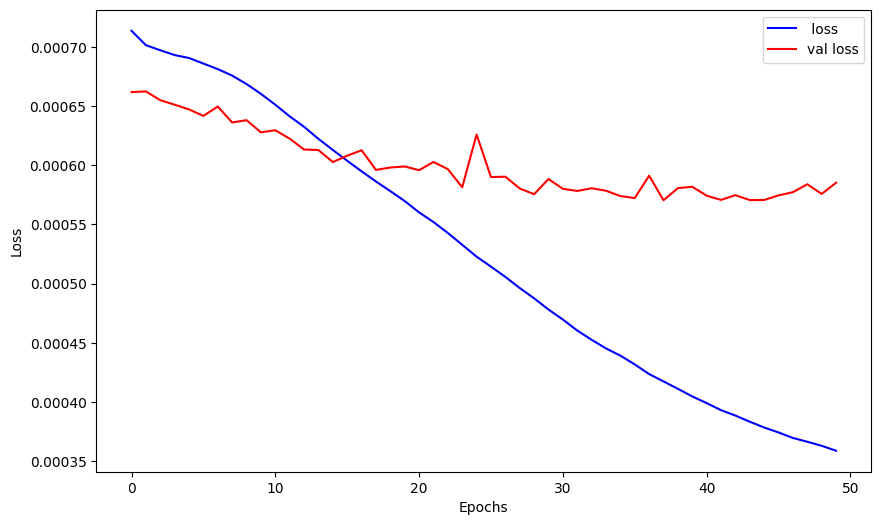

<Figure size 640x480 with 0 Axes>

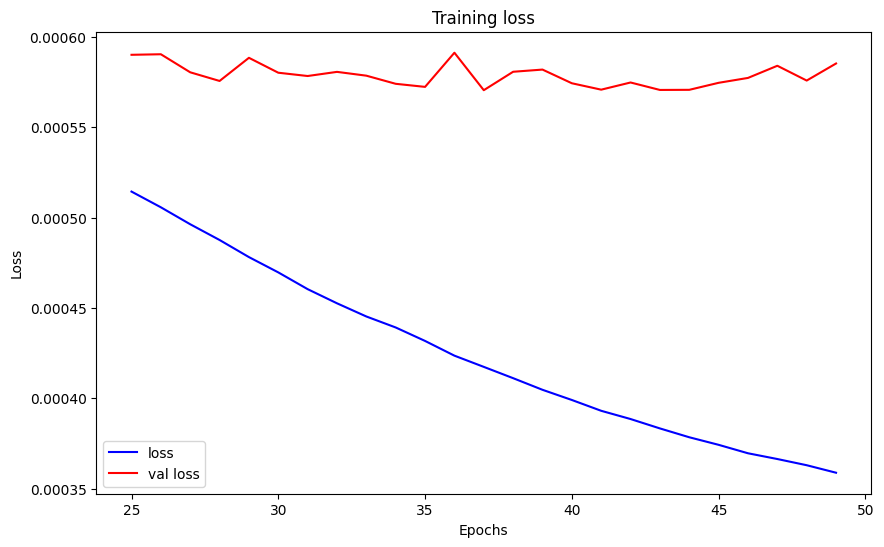

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
def plot_curve(history):
    plt.figure(figsize=(10, 6))

    # — — — — — — — — — — — — — — — — — — — — — — — — — — — — — -
    # Retrieve a list of list results on training and test data
    # sets for each training epoch
    # — — — — — — — — — — — — — — — — — — — — — — — — — — — — — -
    loss=history.history['loss']
    val_loss = history.history['val_loss']
    epochs=range(len(loss)) # Get number of epochs
    # — — — — — — — — — — — — — — — — — — — — — — — —
    # Plot training and validation loss per epoch
    # — — — — — — — — — — — — — — — — — — — — — — — —
    plt.plot(epochs, loss, 'b', label = ' loss')
    plt.plot(epochs, val_loss, 'r', label = 'val loss')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.figure()
    zoomed_loss = loss[25:]
    zoomed_val_loss = val_loss[25:]
    zoomed_epochs = range(25,50)
    # — — — — — — — — — — — — — — — — — — — — — — — —
    # Plot training and validation loss per epoch
    # — — — — — — — — — — — — — — — — — — — — — — — —
    plt.figure(figsize=(10, 6))

    plt.plot(zoomed_epochs, zoomed_loss, 'b', label = 'loss')
    plt.plot(zoomed_epochs, zoomed_val_loss, 'r', label = 'val loss')
    plt.title('Training loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.figure()

plot_curve(cnn_history)

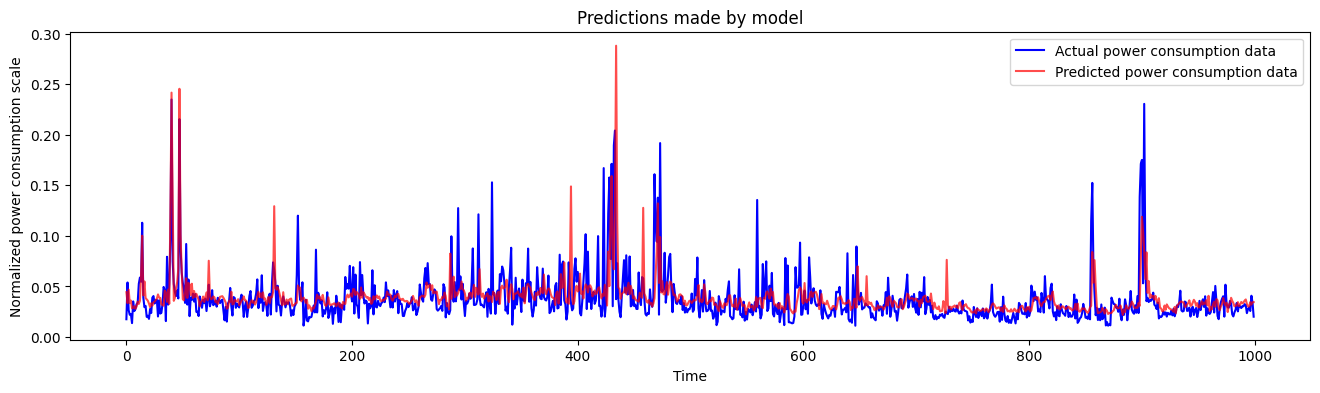

In [ ]:
def plot_predictions(test, predicted, title):
    plt.figure(figsize=(16, 4))

    plt.plot(test, color='blue', label='Actual power consumption data')
    plt.plot(predicted, alpha=0.7, color='red', label='Predicted power consumption data')

    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Normalized power consumption scale')

    plt.legend()
    plt.show()


plot_predictions(y_test[:1000], tf.squeeze(cnnlstm_pred[:1000]), "Predictions made by model")

In [ ]:
y_test[:10] - tf.squeeze(cnnlstm_pred[:10])

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([-0.0267431 ,  0.0204068 , -0.02029125, -0.01151062, -0.01357679,
       -0.01465748,  0.00655741, -0.00488413, -0.00030832,  0.00233362],
      dtype=float32)>

In [ ]:
tf.squeeze(cnnlstm_pred[:10])

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.04436039, 0.03355461, 0.04690211, 0.0334939 , 0.0361013 ,
       0.02845003, 0.02869522, 0.03056587, 0.02796558, 0.03010456],
      dtype=float32)>

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE"""
    error=np.array(np.abs((y_true - y_pred) / y_true))
    mse=np.mean(error,axis=0) * 100
    return mse

In [ ]:
# mean_absolute_percentage_error(y_test, cnnlstm_pred)

In [ ]:
def eval_score(y_test, y_true):
    mae = mean_absolute_error(y_test, y_true)
    mse = mean_squared_error(y_test, y_true)


    return f"mae : {mae}, mse : {mse}"

In [ ]:
eval_score(y_test, cnnlstm_pred)

'mae : 0.012763712705314194, mse : 0.0005330741050143303'

In [ ]:
def evluation(real,pred,data,data_name):
    """Real: the true value
       Pred: predicted value
       Data: the name of data"""
    dataset = data.iloc[:,11].astype('float32')
    max_value = np.max(dataset)
    min_value = np.min(dataset)
    scalar = max_value - min_value
    pred=pd.DataFrame(list(map(lambda x: x*scalar+min_value ,pred)))
    real=pd.DataFrame(list(map(lambda x: x*scalar+min_value ,real)))
    mse=mean_squared_error(real,pred)
    print("MSE of %s is %f"%(data_name,mse))
    mae=mean_absolute_error(real,pred)
    print("MAE of %s is %f"%(data_name,mae))
    rmse=np.sqrt(mean_squared_error(real,pred))
    print("RMSE of %s is %f"%(data_name,rmse))
#     mape=mean_absolute_percentage_error(real,pred)
#     print("MAPE of %s is %f"%(data_name,mape))

In [ ]:
evluation(y_test, tf.squeeze(cnnlstm_pred), stedin_df, 'stedin-data')

MSE of stedin-data is 6551093.973203
MAE of stedin-data is 1414.946899
RMSE of stedin-data is 2559.510495
